<a href="https://colab.research.google.com/github/alatasyusuf521-commits/pekistirmeli_-renme_ile_donmus_gol_gorevi/blob/main/Peki%C5%9Ftirmeli_%C3%96%C4%9Frenme_ile_Donmu%C5%9F_G%C3%B6l_G%C3%B6revi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#environment tanıma
import gym
import random
import numpy as np
!pip install "numpy<2.0"

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [2]:
environment = gym.make("FrozenLake-v1", is_slippery = False, render_mode = "ansi")

/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


In [3]:
environment.reset()# environment reset fonksiyonu
print(environment.render())

"""
S: Start
G: Hedef (goal)
F: Donmuş (frozen)
H: Delik (hole)
"""

['\n\x1bS\x1bFFF\nFHFH\nFFFH\nHFFG\n']


'\nS: Start\nG: Hedef (goal)\nF: Donmuş (frozen)\nH: Delik (hole)\n'

In [4]:
nb_states = environment.observation_space.n #16
nb_action = environment.action_space.n #4

In [5]:
# Q tabl: states(16) x actions(4)
q_table = np.zeros((nb_states, nb_action))
q_table

"""
0: left
1: down
2: right
3: up
"""

'\n0: left\n1: down\n2: right\n3: up\n'

In [41]:
action = environment.action_space.sample()
new_state, reward, done, info = environment.step(action)
print(environment.render())

['  (Up)\nSFFF\nFHFH\nFFFH\n\x1bH\x1bFFG\n']


In [42]:
import pandas as pd

# 1. Aksiyonu seç ve adımı at
action = environment.action_space.sample() # Veya doğrudan 1 (Down) verebilirsiniz
new_state, reward, done, info = environment.step(action)

# Aksiyon isimleri haritası
action_names = {0: "Left (Sol)", 1: "Down (Aşağı)", 2: "Right (Sağ)", 3: "Up (Yukarı)"}

# 2. Oyun haritasını ekrana yazdır (Oyuncunun yeni konumu kırmızı/vurgulu görünür)
print("--- ANLIK OYUN TAHTASI ---")
print(environment.render())

# 3. Adım sonuçlarını tablo halinde göster
step_data = {
    "Seçilen Aksiyon": [f"{action} - {action_names[action]}"],
    "Yeni Durum (State)": [new_state],
    "Ödül (Reward)": [reward],
    "Oyun Bitti mi? (Done)": [done]
}

df_step = pd.DataFrame(step_data)
print("\n--- ADIM SONUÇ TABLOSU ---")
display(df_step)

--- ANLIK OYUN TAHTASI ---
['  (Up)\nSFFF\nFHFH\nFFFH\n\x1bH\x1bFFG\n']

--- ADIM SONUÇ TABLOSU ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Seçilen Aksiyon,Yeni Durum (State),Ödül (Reward),Oyun Bitti mi? (Done)
0,3 - Up (Yukarı),12,0,True


In [43]:
#q-learning
import matplotlib.pyplot as plt
import gym
import random
import numpy as np

In [44]:
environment  =gym.make("FrozenLake-v1", is_slippery = False)
environment.reset()

/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


0

In [46]:
# q table intialize
qtable = np.zeros((environment.observation_space.n, environment.action_space.n)) # 16 x 4
qtable

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [47]:
#hiperparametre
episodes = 1000 # toplam bölüm sayısı
alpha = 0.5 # learning rate
gamma = 0.9 # discount factor

In [49]:
# list of outcomes to plot
outcomes = []
print(f"q table before training: {qtable}")

q table before training: [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [53]:
#training
for _ in range(episodes):
  state = environment.reset() # çevreyi resetle ve agent ın bulunduğu state değerini al
  done  = False
  outcomes.append("Failure")

  while not done:
    #action seçimi
    if np.max(qtable[state]) > 0:
      action = np.argmax(qtable[state])
    else:
      action = environment.action_space.sample()

    #implement action
    new_state, reward, done, info = environment.step(action)

    #training yani q table updating (güncelleme)
    #update Q(s,a)
    qtable[state, action] = qtable[state, action] + alpha * (reward + gamma*np.max(qtable[new_state]) - qtable[state, action])

    #update state
    state = new_state

    if reward:
      outcomes[-1] = "Success"
print()
print("Qtable after training: ")
print(qtable)


Qtable after training: 
[[0.      0.59049 0.      0.     ]
 [0.      0.      0.      0.     ]
 [0.      0.      0.      0.     ]
 [0.      0.      0.      0.     ]
 [0.      0.6561  0.      0.     ]
 [0.      0.      0.      0.     ]
 [0.      0.      0.      0.     ]
 [0.      0.      0.      0.     ]
 [0.      0.      0.729   0.     ]
 [0.      0.81    0.      0.     ]
 [0.      0.      0.      0.     ]
 [0.      0.      0.      0.     ]
 [0.      0.      0.      0.     ]
 [0.      0.      0.9     0.     ]
 [0.      0.      1.      0.     ]
 [0.      0.      0.      0.     ]]


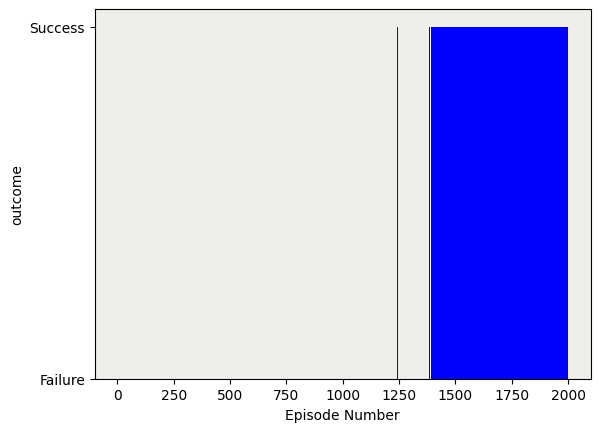

In [58]:
plt.figure()
plt.xlabel("Episode Number")
plt.ylabel("outcome")
ax = plt.gca()
ax.set_facecolor("#efeeea")
plt.bar(range(len(outcomes)), outcomes, color = "blue", width = 1)
plt.show()

In [55]:
qtable

array([[0.     , 0.59049, 0.     , 0.     ],
       [0.     , 0.     , 0.     , 0.     ],
       [0.     , 0.     , 0.     , 0.     ],
       [0.     , 0.     , 0.     , 0.     ],
       [0.     , 0.6561 , 0.     , 0.     ],
       [0.     , 0.     , 0.     , 0.     ],
       [0.     , 0.     , 0.     , 0.     ],
       [0.     , 0.     , 0.     , 0.     ],
       [0.     , 0.     , 0.729  , 0.     ],
       [0.     , 0.81   , 0.     , 0.     ],
       [0.     , 0.     , 0.     , 0.     ],
       [0.     , 0.     , 0.     , 0.     ],
       [0.     , 0.     , 0.     , 0.     ],
       [0.     , 0.     , 0.9    , 0.     ],
       [0.     , 0.     , 1.     , 0.     ],
       [0.     , 0.     , 0.     , 0.     ]])

In [62]:
#evaluation
episodes = 100
nb_success = 0
for _ in range(episodes):
  state = environment.reset()
  done = False

  while not done:
    #choose action
    if np.max(qtable[state] > 0):
      action = np.argmax(qtable[state])
    else:
      action = environment.action_space.sample()
    #implement action
    new_state, reward, done, info = environment.step(action)

    #update agent current state
    state = new_state

    nb_success += reward
print(f"success rate: {100*nb_success/episodes}")


success rate: 100.0
